##### Marketing campaign Outcome Classification model

###### The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to access if the product (bank term deposit) would be ('yes') or not ('no') subscribed. The classification goal is to predict if the client will subscribe a term deposit (variable y)


Definition of Terms

###### - Bank term deposit: A bank term deposit, also known as a fixed deposit (FD), is a low-risk financial product where you deposit a lump sum of money with a bank for a fixed period, or "term," in exchange for a guaranteed, fixed interest rate. You cannot easily access this money until the term ends, but you know exactly how much your investment will earn. 
###### - Default; column: Has credit in default? Having credit in default means you have seriously broken the terms of a credit agreement, typically by failing to make payments for a prolonged period (often 3-6 months), leading the lender to close the account and mark your credit file with a default notice. This significantly damages your credit score, making it harder to get new loans or credit in the future.
###### - Housing; column: Has housing loan? A home loan is a secured loan that is obtained to purchase a property by offering it as collateral. 
###### - Loan; column: Has personal loan? A personal loan is a fixed sum of money you borrow from a lender, like a bank or credit union, and repay in regular installments over an agreed-upon period, typically with interest.
###### - day_of_week: Last contact day of week.
###### - month: Last contact month of year.
###### - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
###### - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
###### - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
###### - previous: number of contacts performed before this campaign and for this client (numeric)
###### - poutcome: outcome of the previous marketing campaign (categorical: "failure","nonexistent","success")
   ###### social and economic context attributes
###### - emp.var.rate: employment variation rate - quarterly indicator (numeric)
###### - cons.price.idx: consumer price index - monthly indicator (numeric)     
###### - cons.conf.idx: consumer confidence index - monthly indicator (numeric)     
###### - euribor3m: euribor 3 month rate - daily indicator (numeric)
###### - nr.employed: number of employees - quarterly indicator (numeric)

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List 

In [2]:
# Setting display options for better readability
pd.set_option('display.max_columns', None)

In [3]:
# Loading the dataset
file_path = 'Dataset/bank-additional.csv'
df = pd.read_csv(file_path, sep=';')

# Displaying the first 5 rows of the dataset
df.head(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,487,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,346,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,227,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,17,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,58,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [4]:
# Displaying df shape
print(f"Dataset shape: {df.shape}")

Dataset shape: (4119, 21)


In [5]:
# Checking for column datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

In [6]:
# Classification class (y) balance
yclass_df = (df['y'].value_counts() * 100 / df.shape[0]).to_frame(name='Per %').reset_index()
yclass_df

,y,Per %
0,no,89.05074
1,yes,10.94926


There is a class imbalance in the data. Maority of the customer did not subscribe to the Portuguese bankinf institution product. 89.05% did not subscribe while 10.95% subscribed 

In [7]:
# Description of all categorical features
df.describe(exclude=['int64', 'float64'])

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,1012,2509,1264,3315,2175,3349,2652,1378,860,3523,3668


In [8]:
# Description of numerical features
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [9]:
# Create age_group feature
age_bins = [18, 23, 30, 40, 50, 60, 90]
age_group = ['18-23', '24-30', '31-40', '41-50', '51-65', '66 and above']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_group, include_lowest=True)

In [10]:
# Renaming some columns
df = df.rename(columns={
    'default': 'credit_default',
    'housing':'housing_loan',
    'loan':'personal_loan'
})

In [ ]:
def CatFeatureCampaignResult(col_list: List[str], df: pd.DataFrame) -> List[pd.DataFrame]:
    
    import warnings
    """
    This function takes a list of categorical columns and a dataframe as input,
    and plot the percentage distribution of each category within those columns
    against the target variable 'y'.
    """
    for col in col_list:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            col_df = (
                df.pivot_table(index=col, columns='y', aggfunc='size')
                .apply(lambda x: 100 * x/x.sum(), axis=1)
            )
            
            col_df.plot(kind='bar', stacked=True, figsize=(10, 5))
            for i, v in enumerate(col_df.values):
                for j, val in enumerate(v):
                    plt.text(i, val/2 + sum(v[:j]), f'{val:.1f}%', ha='center', va='center', color='white', fontsize=8)
            plt.title(f'{col} vs Campaign Result')
            plt.ylabel('Percentage %')
            plt.xlabel(col)
            plt.legend(title='Subscribed to Term Deposit', labels=['No', 'Yes'])
            plt.tight_layout()
            plt.show()


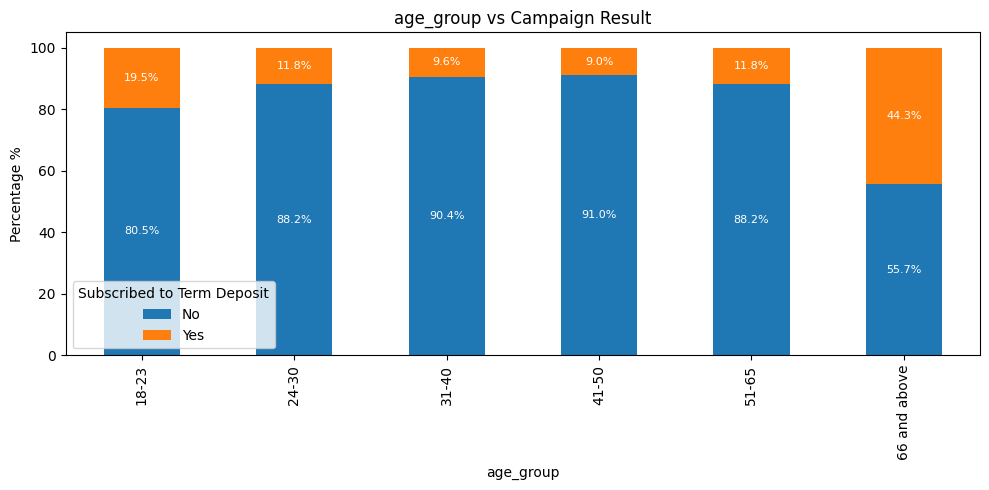

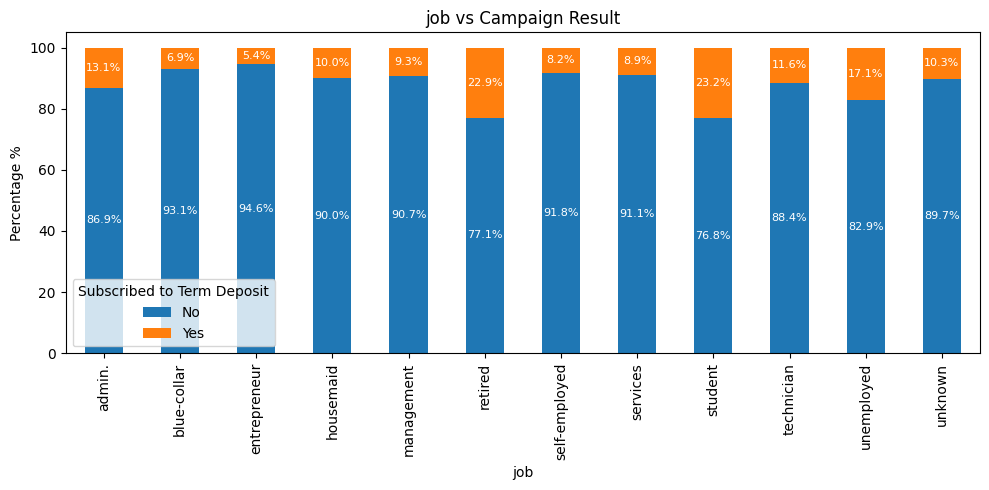

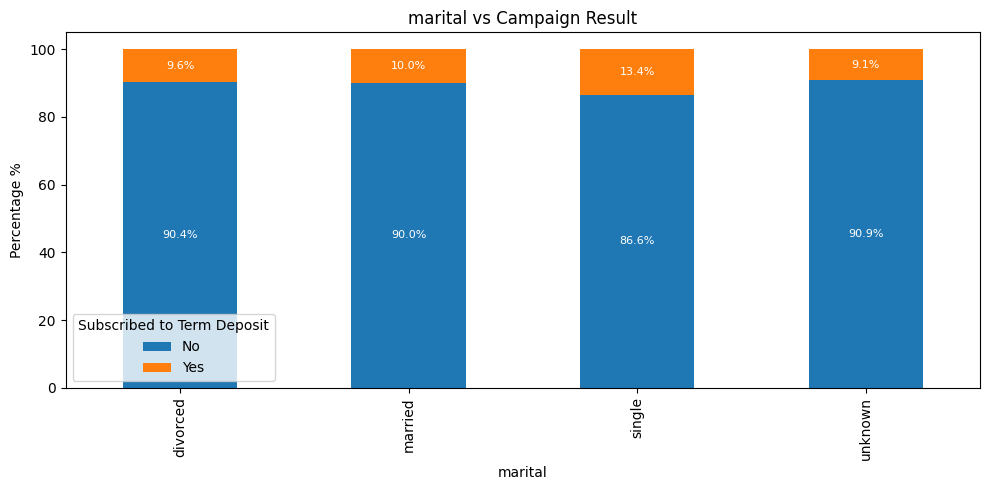

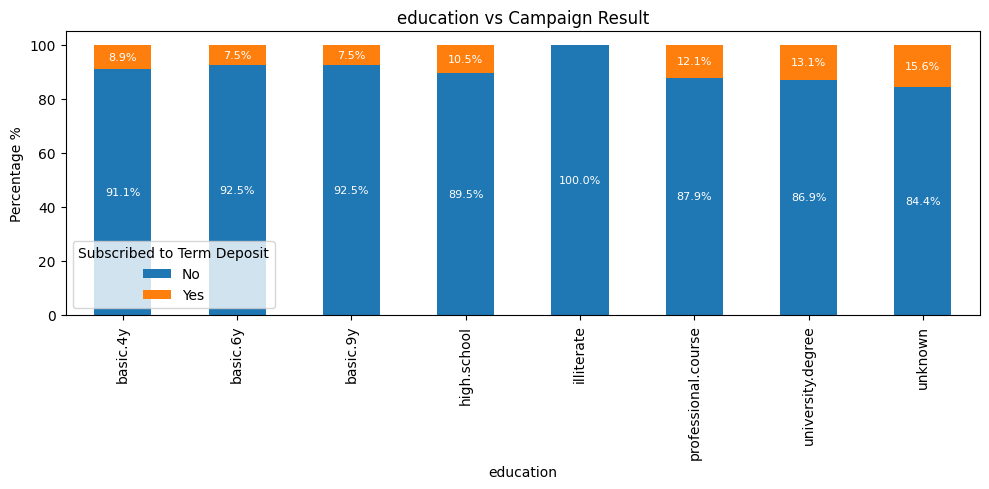

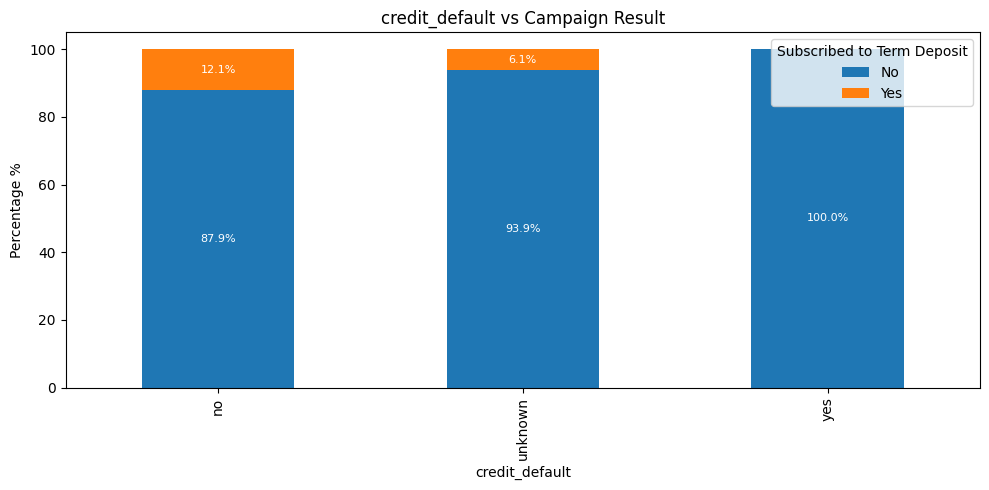

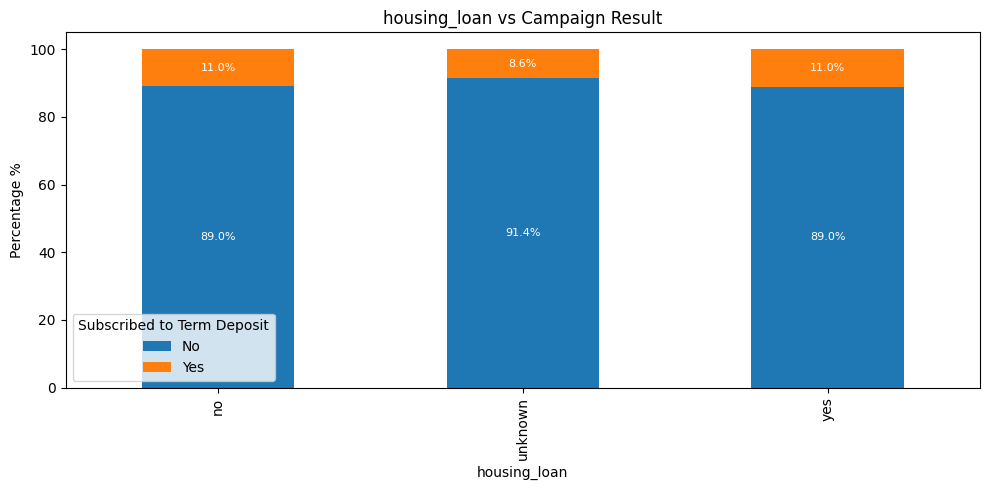

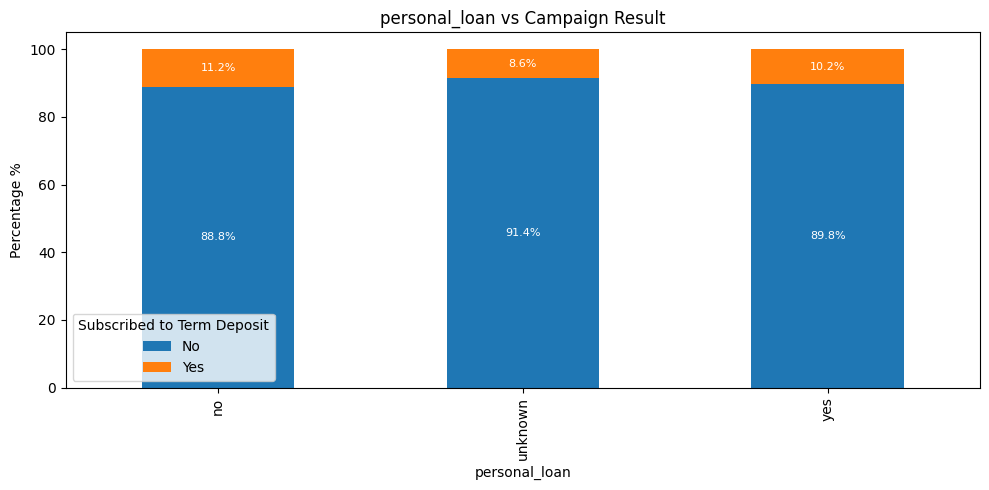

In [48]:
# plot the percentage distribution for each eco_socio_col values against target variable 'y'
eco_socio_col = [
    'age_group', 
    'job', 
    'marital', 
    'education', 
    'credit_default', 
    'housing_loan',
    'personal_loan' 
]
CatFeatureCampaignResult(eco_socio_col, df)